In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("/content/adult.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
print("Shape of dataset:", df.shape)

Shape of dataset: (48842, 15)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


The dataset consists of 48,842 observations and 15 variables, providing a combination of numerical and categorical information about individuals. The presence of both types of features is useful for classification because different aspects such as age, education, occupation, and working hours can provide information for predicting income. Although the dataset does not show any null values, some categorical features contain '?', indicating unknown values that need to be examined and handled during data cleaning.

In [9]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
print(df['income'].value_counts())

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [12]:
income_percentage = df['income'].value_counts(normalize=True) * 100

print(income_percentage.round(2))

income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


The target variable is imbalanced, with 76.08% of individuals belonging to the <=50K income group and only 23.92% belonging to the >50K group. This shows that the lower-income class is considerably more represented in the dataset than the higher-income class.

In [11]:
print(df.duplicated().sum())

52


The dataset contains 52 duplicate records. These records may represent repeated observations and could affect the model if they are retained, as the same information may be given more importance during training.

In [13]:
unknown_values = (df == '?').sum()

unknown_values = unknown_values[unknown_values > 0]

print(unknown_values)

workclass         2799
occupation        2809
native-country     857
dtype: int64


The dataset contains unknown values represented by ? in three categorical features: workclass has 2,799 unknown values, occupation has 2,809, and native-country has 857. These values are not detected as null values because they are stored as text. Therefore, they need to be treated as missing values during data cleaning before applying categorical encoding and model training.

In [14]:
unknown_counts = (df == '?').sum()
unknown_percentage = (unknown_counts / len(df)) * 100
unknown_table = pd.DataFrame({
    'Unknown Values': unknown_counts,
    'Percentage': unknown_percentage.round(2)
})

unknown_table = unknown_table[unknown_table['Unknown Values'] > 0]
unknown_table

,Unknown Values,Percentage
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


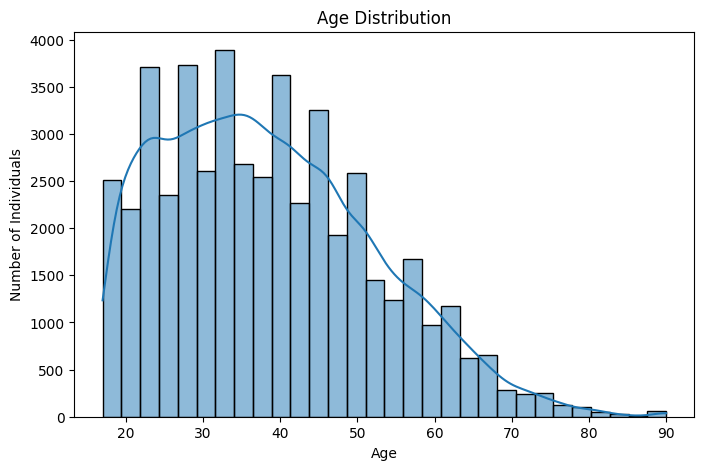

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Individuals')
plt.show()

The age distribution is concentrated mainly between 20 and 50 years, with the highest number of individuals around the early to mid-30s. The distribution is slightly right-skewed, with fewer individuals at older ages. Age may be useful for predicting income, especially along with education, occupation, and working hours.

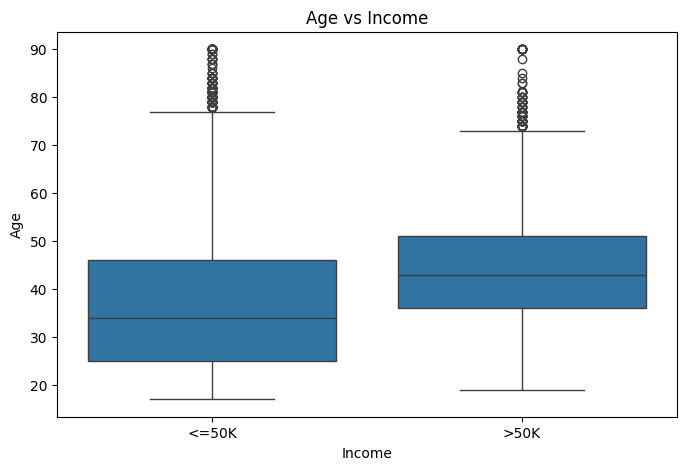

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='age')
plt.title('Age vs Income')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

The >50K income group has a higher median age than the ≤50K group, showing that higher income is more common among middle-aged individuals. However, the two groups still overlap considerably, so age alone cannot predict income and should be considered with other features such as education and occupation.


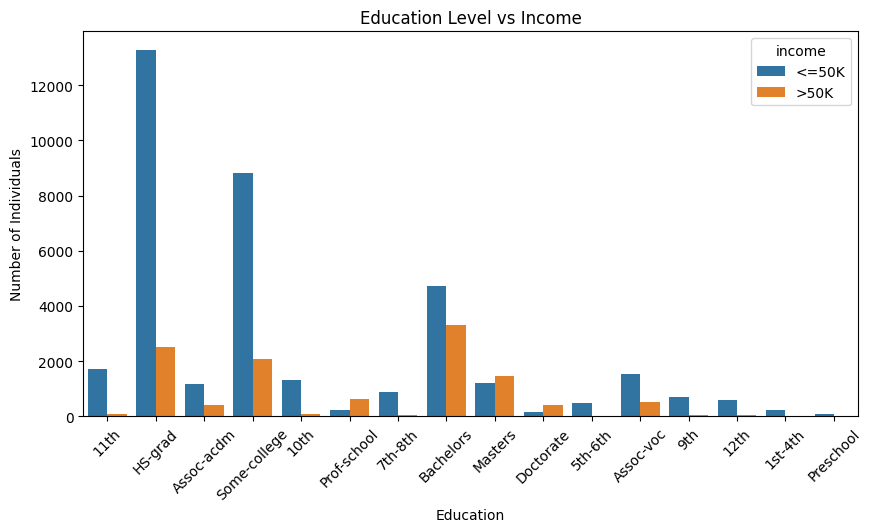

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', hue='income')
plt.title('Education Level vs Income')
plt.xlabel('Education')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45)
plt.show()

Income varies noticeably with education level. Individuals with higher education levels, especially Bachelors, Masters, Prof-school, and Doctorate, have a higher proportion of >50K income. Lower education levels are mostly concentrated in the <=50K group. This suggests that education is an important feature for predicting income.

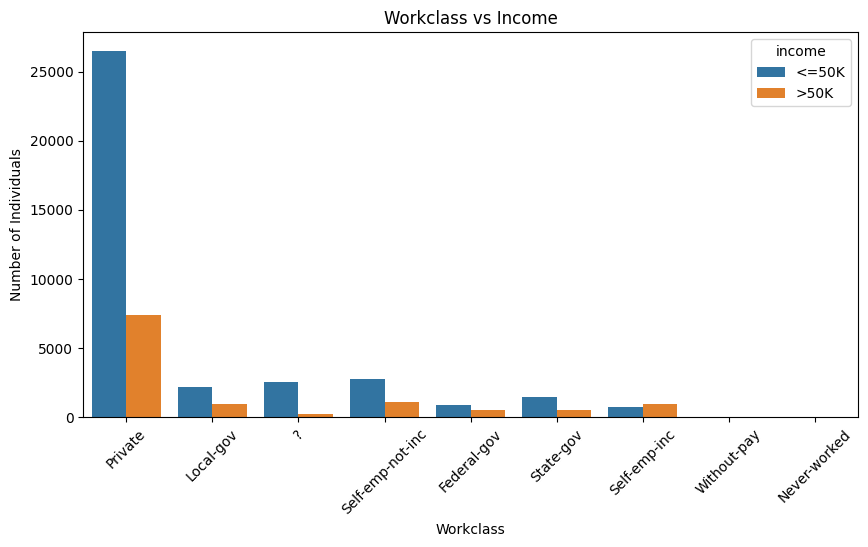

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='workclass', hue='income')
plt.title('Workclass vs Income')
plt.xlabel('Workclass')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45)
plt.show()

The Private workclass has the highest number of individuals, while Self-emp-inc has a relatively higher proportion of >50K earners. Government workclasses also show a noticeable share of higher-income individuals. Overall, workclass shows some relationship with income, but the pattern is weaker than education.


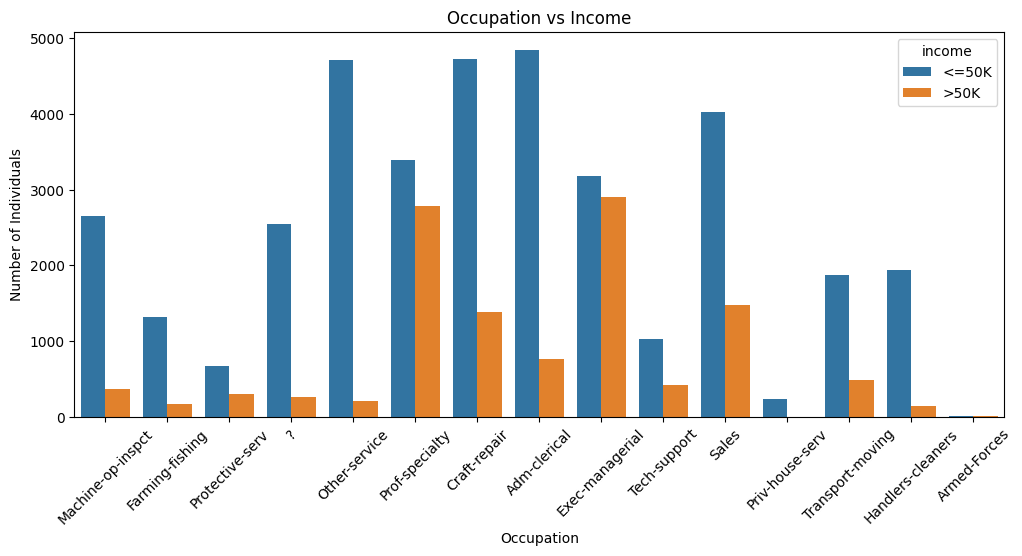

In [19]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='occupation', hue='income')
plt.title('Occupation vs Income')
plt.xlabel('Occupation')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45)
plt.show()

Occupation shows a clear relationship with income. Exec-managerial and Prof-specialty have a much higher proportion of >50K earners, while occupations such as Other-service, Handlers-cleaners, and Priv-house-serv are mostly <=50K. This suggests that occupation is an important feature for predicting income.

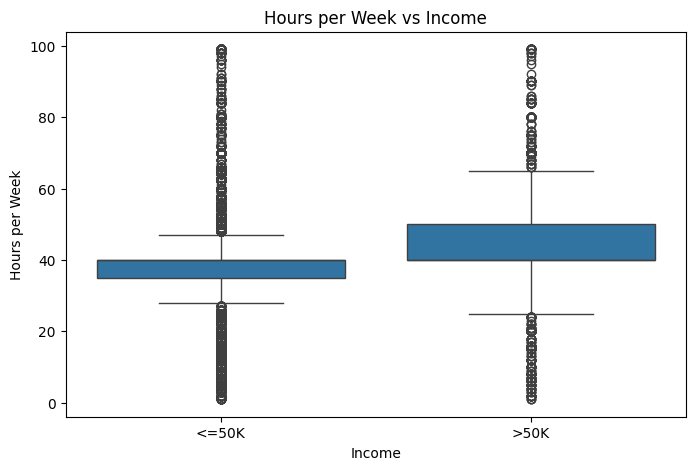

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week vs Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

The >50K income group generally works more hours per week than the <=50K group, although the two groups still overlap. This suggests that hours-per-week can help predict income, especially when combined with features such as occupation and education

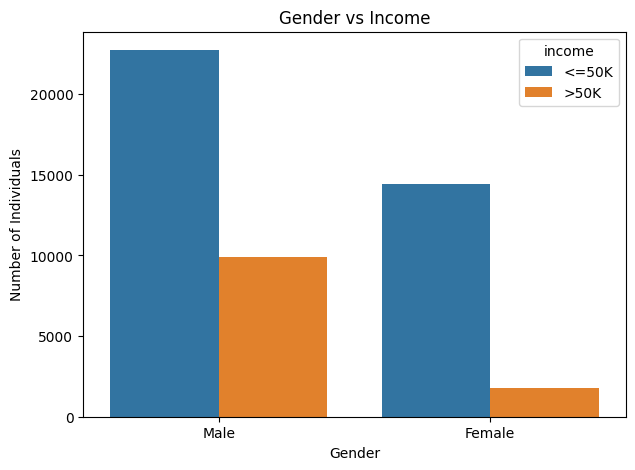

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='gender', hue='income')
plt.title('Gender vs Income')
plt.xlabel('Gender')
plt.ylabel('Number of Individuals')
plt.show()

The >50K income group has a higher proportion of males than females in this dataset. This shows a noticeable association between gender and income. However, this relationship may also be influenced by other factors such as occupation, education, and working hours, so gender should not be interpreted as a direct cause of income.

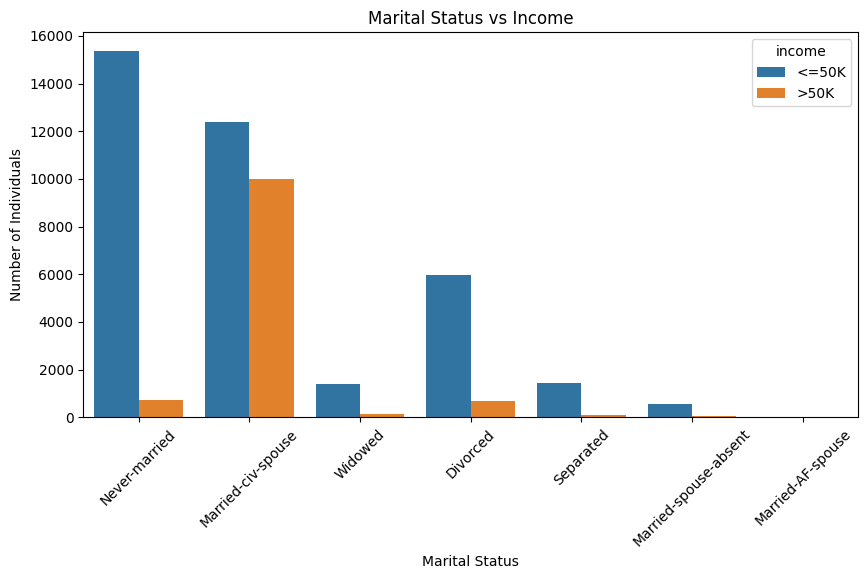

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='marital-status', hue='income')
plt.title('Marital Status vs Income')
plt.xlabel('Marital Status')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45)
plt.show()

Married-civ-spouse has a much higher proportion of >50K earners than the other marital-status groups. Most other categories are strongly concentrated in <=50K. This shows that marital status has a strong association with income, although it may also be related to factors such as age and relationship status.

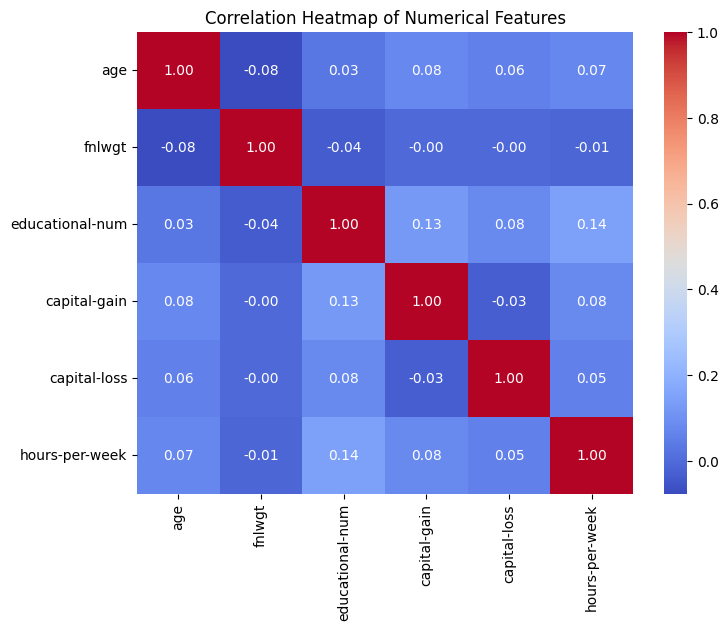

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The numerical features show very weak correlations with each other, with the strongest correlation being only about 0.14. This indicates that there is little multicollinearity among the numerical variables. However, correlation alone does not show how strongly these features predict income, so further analysis is needed.

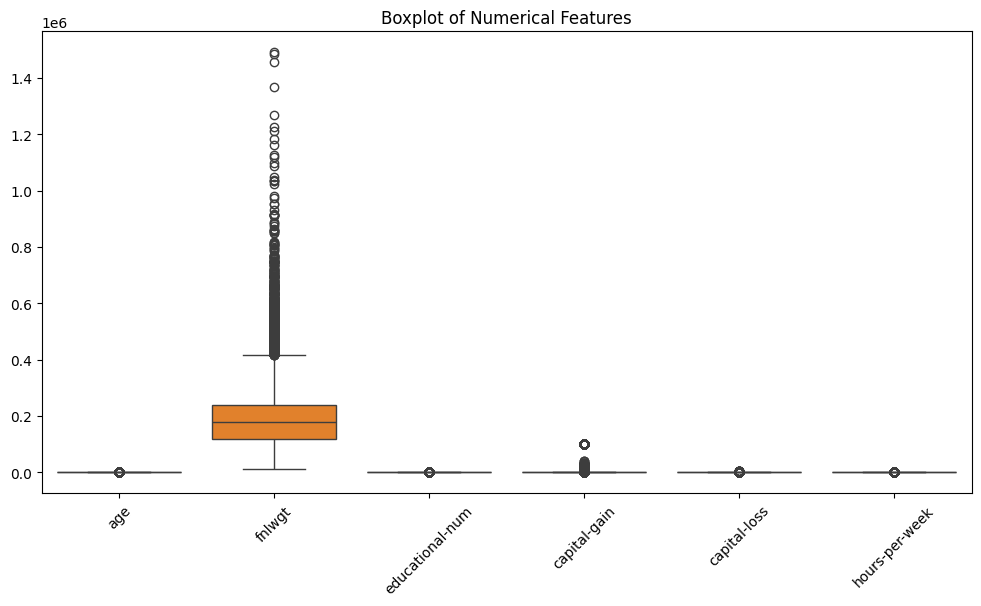

In [24]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

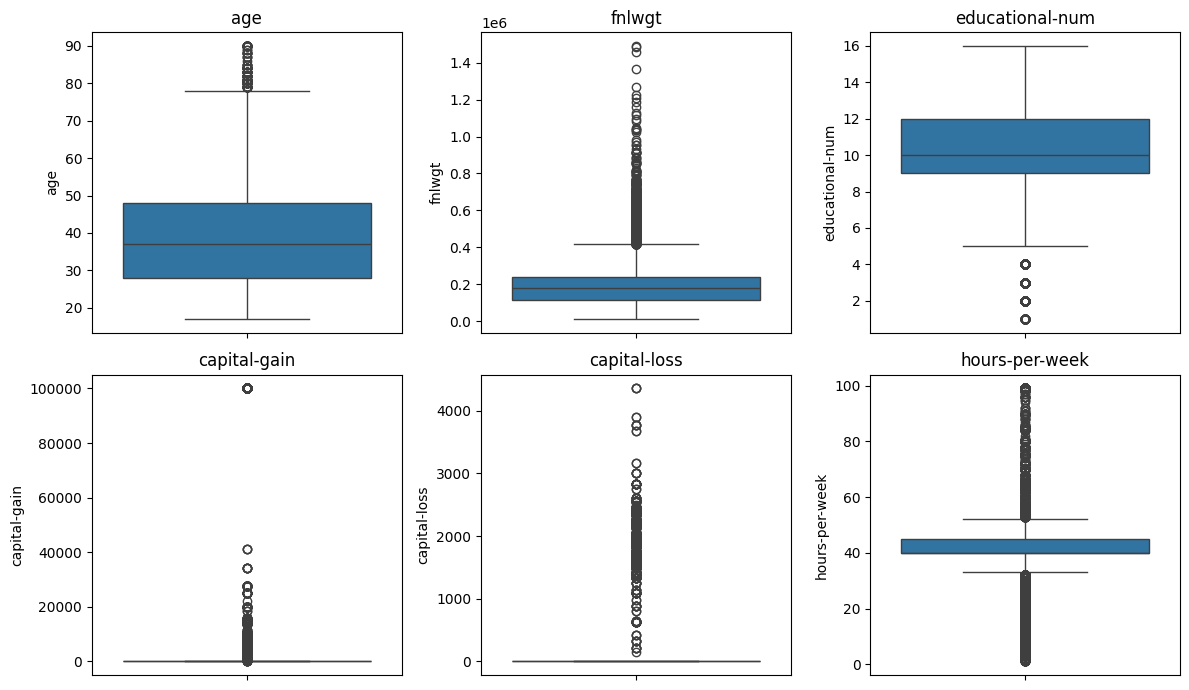

In [25]:
num_cols = ['age', 'fnlwgt', 'educational-num',
            'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)

plt.tight_layout()
plt.show()

The boxplots show that the numerical features have different distributions and contain several extreme values. age and hours-per-week have some values far from their main ranges, while fnlwgt is strongly right-skewed. capital-gain and capital-loss are highly concentrated at 0, with a small number of much larger values. educational-num has a relatively narrow range, with a few rare values at the lower end. These patterns show that the numerical features need to be examined carefully during data cleaning and preprocessing rather than treating all outliers in the same way

**Conclusion of EDA:**

The EDA shows that income is associated with several features, particularly education, occupation, age, working hours, marital status, and gender. It also revealed important data-quality issues, including unknown values, duplicate records, class imbalance, skewed distributions, and extreme values in some numerical features. These findings will be used to decide how the data should be cleaned and prepared before model training.

In [26]:
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(col, ":", count)

workclass : 2799
occupation : 2809
native-country : 857


In [27]:
df.replace('?', np.nan, inplace=True)

print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [28]:
categorical_cols = ['workclass', 'occupation', 'native-country']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df[categorical_cols].isnull().sum())

workclass         0
occupation        0
native-country    0
dtype: int64


In [29]:
print("Duplicate rows before removal:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

Duplicate rows before removal: 53
Duplicate rows after removal: 0
Shape after removing duplicates: (48789, 15)


In [30]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Final shape:", df.shape)

Total missing values: 0
Total duplicate rows: 0
Final shape: (48789, 15)


The data cleaning process successfully resolved the major data-quality issues identified during EDA. The dataset now contains complete records without missing values or duplicate rows, making it suitable for the next stages of preprocessing and model development.

In [31]:
df.drop('fnlwgt', axis=1, inplace=True)

print(df.shape)
print(df.columns)

(48789, 14)
Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')


In [32]:
df['has_capital_gain'] = (df['capital-gain'] > 0).astype(int)
df['has_capital_loss'] = (df['capital-loss'] > 0).astype(int)

print(df[['capital-gain', 'has_capital_gain',
          'capital-loss', 'has_capital_loss']].head())

   capital-gain  has_capital_gain  capital-loss  has_capital_loss
0             0                 0             0                 0
1             0                 0             0                 0
2             0                 0             0                 0
3          7688                 1             0                 0
4             0                 0             0                 0


In [33]:
print(df[['has_capital_gain', 'has_capital_loss']].sum())

has_capital_gain    4035
has_capital_loss    2282
dtype: int64


The new binary features successfully capture whether an individual has any capital gain or capital loss. This is useful because the original capital-gain and capital-loss variables are highly concentrated around zero, so the binary indicators make the presence of these values more explicit for the model.

We have also removed fnlwgt because it is a sampling weight and was highly skewed.

In [34]:
X = df.drop('income', axis=1)
y = df['income']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48789, 15)
Target shape: (48789,)


In [35]:
numerical_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Numerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

Numerical features:
['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'has_capital_loss']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [36]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

print("Encoded shape:", X_encoded.shape)

Encoded shape: (48789, 99)


In [37]:
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)
X_final = pd.concat(
    [X[numerical_cols], X_encoded_df],
    axis=1
)
print("Final feature shape:", X_final.shape)

Final feature shape: (48789, 106)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (39031, 106)
Testing set: (9758, 106)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling completed.")

Scaling completed.


In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['<=50K' '>50K']


In [41]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train_encoded)
print("Logistic Regression training completed.")

Logistic Regression training completed.


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test_encoded, y_pred_lr)
precision_lr = precision_score(y_test_encoded, y_pred_lr)
recall_lr = recall_score(y_test_encoded, y_pred_lr)
f1_lr = f1_score(y_test_encoded, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-score :", f1_lr)

Logistic Regression Results
Accuracy : 0.853556056568969
Precision: 0.7385586533403472
Recall   : 0.601027397260274
F1-score : 0.6627330658484777


The Logistic Regression model achieved 85.36% accuracy, with 73.86% precision, 60.10% recall, and 66.27% F1-score. The model performs reasonably well overall, but its lower recall shows that it misses some individuals with income above $50K. Since the classes are imbalanced, F1-score, precision, and recall are also important for evaluation.

In [43]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train_encoded)

y_pred_dt = decision_tree.predict(X_test)

accuracy_dt = accuracy_score(y_test_encoded, y_pred_dt)
precision_dt = precision_score(y_test_encoded, y_pred_dt)
recall_dt = recall_score(y_test_encoded, y_pred_dt)
f1_dt = f1_score(y_test_encoded, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-score :", f1_dt)

Decision Tree Results
Accuracy : 0.8103094896495183
Precision: 0.6028850233347476
Recall   : 0.608304794520548
F1-score : 0.6055827828681014


The Decision Tree achieved 81.03% accuracy, with 60.29% precision, 60.83% recall, and 60.56% F1-score. Its performance is lower than Logistic Regression, especially in precision and F1-score, indicating that the basic Decision Tree does not perform as well on this dataset.

In [44]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train_encoded)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
precision_rf = precision_score(y_test_encoded, y_pred_rf)
recall_rf = recall_score(y_test_encoded, y_pred_rf)
f1_rf = f1_score(y_test_encoded, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

Random Forest Results
Accuracy : 0.8421807747489239
Precision: 0.6889838556505223
Recall   : 0.6211472602739726
F1-score : 0.6533093201260693


The Random Forest achieved 84.22% accuracy, with 68.90% precision, 62.11% recall, and 65.33% F1-score. It performed slightly better than the Decision Tree in recall, but its overall performance was still lower than Logistic Regression.

In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train_encoded)

y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test_encoded, y_pred_knn)
precision_knn = precision_score(y_test_encoded, y_pred_knn)
recall_knn = recall_score(y_test_encoded, y_pred_knn)
f1_knn = f1_score(y_test_encoded, y_pred_knn)

print("KNN Results")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1-score :", f1_knn)

KNN Results
Accuracy : 0.8321377331420373
Precision: 0.6567834681042228
Recall   : 0.6258561643835616
F1-score : 0.6409469530907497


The KNN model achieved 83.21% accuracy, with 65.68% precision, 62.59% recall, and 64.09% F1-score. Its recall is slightly higher than Random Forest, but its overall performance is still below Logistic Regression.


In [46]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_knn
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_knn
    ],
    'F1-score': [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_knn
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.853556,0.738559,0.601027,0.662733
1,Decision Tree,0.810309,0.602885,0.608305,0.605583
2,Random Forest,0.842181,0.688984,0.621147,0.653309
3,KNN,0.832138,0.656783,0.625856,0.640947


Logistic Regression achieved the highest accuracy (85.36%) and F1-score (66.27%) among the four models. KNN had the highest recall (62.59%), while Decision Tree had the lowest overall performance across the main metrics. These results show that the models perform differently, so accuracy alone is not enough for comparison.

In [47]:
X = df.drop('income', axis=1)
y = df['income']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_raw.shape)
print("Testing set:", X_test_raw.shape)

Training set: (39031, 15)
Testing set: (9758, 15)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numerical_cols = [
    'age',
    'educational-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'has_capital_gain',
    'has_capital_loss'
]

categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

final_lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

final_lr_pipeline.fit(X_train_raw, y_train)

print("Pipeline training completed.")

Pipeline training completed.


In [52]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_lr_pipeline,
    X_train_raw,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("Cross-validation F1-scores:", cv_scores)
print("Mean CV F1-score:", cv_scores.mean())

Cross-validation F1-scores: [0.78199578 0.78463545 0.77890686 0.79164782 0.79165453]
Mean CV F1-score: 0.7857680866125932


The Logistic Regression pipeline achieved a mean cross-validation F1-score of 78.58%, with similar scores across all five folds. This indicates that the model's performance is fairly consistent across different subsets of the training data.

In [53]:
from sklearn.metrics import classification_report

y_pred_final = final_lr_pipeline.predict(X_test_raw)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7422
        >50K       0.74      0.60      0.66      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.77      0.78      9758
weighted avg       0.85      0.85      0.85      9758



The Logistic Regression model achieved 85% accuracy and 78% macro F1-score on the test set. It performed better for the <=50K class (F1 = 91%) than the >50K class (F1 = 66%). The results are consistent with the cross-validation score of 78.58%, showing stable performance.

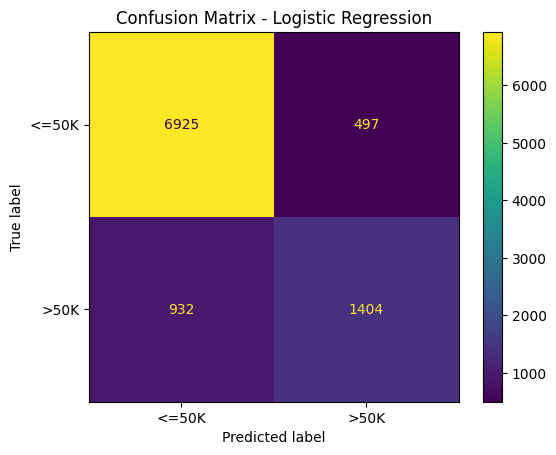

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final, labels=['<=50K', '>50K'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['<=50K', '>50K']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model performs better for the <=50K class than the >50K class. It correctly identified most <=50K samples, but it missed some >50K samples. This is mainly related to the class imbalance in the dataset, so accuracy alone should not be used to evaluate the model.

In [55]:
import joblib
joblib.dump(final_lr_pipeline, 'adult_income_logistic_regression.pkl')
print("Model saved successfully.")

Model saved successfully.


In [56]:
loaded_model = joblib.load('adult_income_logistic_regression.pkl')

y_pred_loaded = loaded_model.predict(X_test_raw)

print("Model loaded successfully.")
print("Predictions made successfully.")

Model loaded successfully.
Predictions made successfully.


The final Logistic Regression pipeline was successfully saved and loaded using Joblib. The loaded model also made predictions successfully, confirming that the saved model can be reused for future predictions.